# Setup

In [1]:
import sys, os
from dotenv import load_dotenv

IN_COLAB = ('google.colab' in sys.modules)

if IN_COLAB:
    from google.colab import drive, userdata
    drive.mount('/content/drive')

    BASE_PATH = '/content/drive/MyDrive/python/text-autocomplete-rnn'

    sys.path.insert(0, BASE_PATH)

    os.environ['CLEARML_KEY'] = userdata.get('CLEARML_KEY')
    os.environ['CLEARML_SECRET'] = userdata.get('CLEARML_SECRET')
else:
    BASE_PATH = os.getcwd()
    load_dotenv()

In [2]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm.auto import tqdm
from torch.utils.data import random_split
from transformers import BertTokenizerFast
from torch.optim import Adam

import datetime
import urllib.request

from src import data_utils, lstm_model, seq2seq_model, monitoring, model_eval
from src.next_token_dataset import NextTokenDataset, next_token_data_loader
from src.eval_transformer import evaluate_transformer

/Users/okarpunina/projects/python/ya-dl-nlp/text-autocomplete-rnn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device} device')

config_file_path = os.path.join(BASE_PATH, 'configs/config.yaml')

with open(config_file_path, 'r') as file:
    config = yaml.safe_load(file)

ORIGINAL_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], config['dataset']['original_filename'])

basename = os.path.basename(config['dataset']['original_filename'])
DATASET_BASENAME = os.path.splitext(basename)[0]

PREPROCESSED_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_preprocessed.csv')
TRAIN_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_train.csv')
VAL_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_val.csv')
TEST_DATASET_PATH = os.path.join(BASE_PATH, config['dataset']['dir'], f'{DATASET_BASENAME}_test.csv')

MODEL_DIR = os.path.join(BASE_PATH, config['model']['dir'])

MAX_SEQ_LENGTH = 30

monitoring.init_clearml(config['clearml'])



Using cpu device
ClearML disabled


# Data preprocessing

In [4]:
if not os.path.exists(ORIGINAL_DATASET_PATH):
    urllib.request.urlretrieve(config['dataset']['source'], ORIGINAL_DATASET_PATH)

In [5]:
if not os.path.exists(PREPROCESSED_DATASET_PATH):
    dataset = data_utils.load_data(ORIGINAL_DATASET_PATH)

    preprocessed = [data_utils.clear_text(line) for line in dataset]
    preprocessed = [line for line in preprocessed if line != '']

    data_utils.store_data(preprocessed, PREPROCESSED_DATASET_PATH)

    dataset = preprocessed
else:
    dataset = np.array(data_utils.load_data(PREPROCESSED_DATASET_PATH))

# Data Exploration

Всего примеров: 1596935
Статистика по количеству строк:
Среднее: 13.15
Медиана: 12.00
5%: 3.00
95%: 26.00


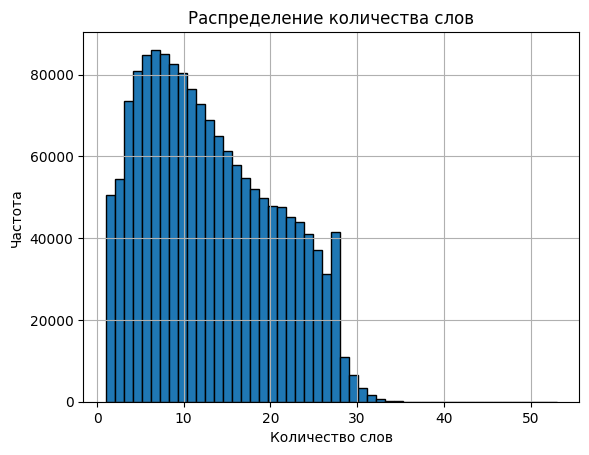

In [6]:
words_count = np.array([len(line.split()) for line in dataset])

print(f'Всего примеров: {len(dataset)}')
print('Статистика по количеству строк:')
print(f'Среднее: {np.mean(words_count):.2f}')
print(f'Медиана: {np.median(words_count):.2f}')
print(f'5%: {np.percentile(words_count, 5):.2f}')
print(f'95%: {np.percentile(words_count, 95):.2f}')

plt.hist(words_count, bins=50, edgecolor='black')
plt.title("Распределение количества слов")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

Большинство данных имеет от 3 до 26 слов, что позволит использовать несложные RNN

# Data Preparation

In [7]:
if (not os.path.exists(TRAIN_DATASET_PATH) or 
    not os.path.exists(VAL_DATASET_PATH) or 
    not os.path.exists(VAL_DATASET_PATH)):

    val_size = int(len(dataset) * 0.1)
    test_size = val_size
    train_size = len(dataset) - val_size - test_size

    torch.manual_seed(42)
    train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

    data_utils.store_data(train_data, TRAIN_DATASET_PATH)
    data_utils.store_data(val_data, VAL_DATASET_PATH)
    data_utils.store_data(test_data, TEST_DATASET_PATH)
else:
    train_data = data_utils.load_data(TRAIN_DATASET_PATH)
    val_data = data_utils.load_data(VAL_DATASET_PATH)
    test_data = data_utils.load_data(TEST_DATASET_PATH)

max_examples = config['dataset']['max_examples']
if max_examples > 0:
    train_data = train_data.dataset[:max_examples] if isinstance(train_data, torch.utils.data.dataset.Subset) else train_data[:max_examples]
    val_data = val_data.dataset[:max_examples] if isinstance(val_data, torch.utils.data.dataset.Subset) else val_data[:max_examples]
    test_data = test_data.dataset[:max_examples] if isinstance(test_data, torch.utils.data.dataset.Subset) else test_data[:max_examples]

print(f'Train size: {len(train_data)}')
print(f'Val size: {len(val_data)}')
print(f'Test size: {len(test_data)}')


Train size: 1000
Val size: 1000
Test size: 1000


In [8]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# чтобы не добавлять новых токенов, будем считать CLS за начало фразы, SEP за конец
special_tokens = tokenizer.special_tokens_map
BOS_TOKEN_ID = tokenizer.convert_tokens_to_ids(special_tokens['cls_token'])
EOS_TOKEN_ID = tokenizer.convert_tokens_to_ids(special_tokens['sep_token'])
PAD_TOKEN_ID = tokenizer.convert_tokens_to_ids(special_tokens['pad_token'])


In [9]:
# для тренировки входные тексты режутся по каждому токену
print('Creating train dataset')
train_dataset = NextTokenDataset(
    train_data,
    tokenizer,
    bos_token_id=BOS_TOKEN_ID,
    eos_token_id=EOS_TOKEN_ID,
    pad_token_id=PAD_TOKEN_ID,
    max_output_length=MAX_SEQ_LENGTH,
    split_mode='all'
)
# для валидации и теста три четверти текста - промпт, четверть - таргет
print('Creating val dataset')
val_dataset = NextTokenDataset(
    val_data,
    tokenizer,
    bos_token_id=BOS_TOKEN_ID,
    eos_token_id=EOS_TOKEN_ID,
    pad_token_id=PAD_TOKEN_ID,
    max_output_length=MAX_SEQ_LENGTH,
    split_mode='quarter'
)
print('Creating test dataset')
test_dataset = NextTokenDataset(
    test_data,
    tokenizer,
    bos_token_id=BOS_TOKEN_ID,
    eos_token_id=EOS_TOKEN_ID,
    pad_token_id=PAD_TOKEN_ID,
    max_output_length=MAX_SEQ_LENGTH,
    split_mode='quarter'
)

batch_size = config['train']['batch_size']

train_loader = next_token_data_loader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = next_token_data_loader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = next_token_data_loader(test_dataset, batch_size=batch_size, shuffle=False)

Creating train dataset


100%|██████████| 1000/1000 [00:00<00:00, 13491.67it/s]


Creating val dataset


100%|██████████| 1000/1000 [00:00<00:00, 19493.07it/s]


Creating test dataset


100%|██████████| 1000/1000 [00:00<00:00, 21055.74it/s]


# Training

In [10]:
def save_model(model, run_id, epoch):
    filename = f'{run_id}-{epoch}.pth'
    torch.save(model.state_dict(), os.path.join(MODEL_DIR, filename))

## LSTM

Модель предсказывает следующий токен по принципу классификатора. В режиме генерации текста рекурсивно генерирует по одному токену

In [11]:

model = lstm_model.NextTokenLSTMPredictor(
    tokenizer.vocab_size,
    hidden_dim=config['model']['hidden_dim']
)

In [ ]:
TRAIN_LSTM = True

# lstm_load = '_lstm_weights-20260303_074124-20.pth'
lstm_load = False

if lstm_load:
    lstm_weights = torch.load(os.path.join(MODEL_DIR, lstm_load))
    model.load_state_dict(lstm_weights)
    TRAIN_LSTM = False

In [ ]:
if TRAIN_LSTM:
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)

    now = datetime.datetime.now()
    run_id = f'lstm_weights-{now.strftime('%Y%m%d_%H%M%S')}'

    task_config = {
        'run_id': run_id,
        'device': device,
        'dataset_size': len(train_dataset),
        'batch_size': config['train']['batch_size'],
        'epochs': config['train']['max_epoch'],
        'hidden size': config['model']['hidden_dim'],
    }

    model.to(device)

    with monitoring.ClearMLTask(project_name='RNN Autocomplete', task_name='LSTM model', task_config=task_config) as task:
        for epoch in range(config['train']['max_epoch']):
            loss = lstm_model.lstm_train_epoch(train_loader, model, criterion, optimizer, device)
            rouge1, rouge2 = model_eval.evaluate_model(model, val_loader, tokenizer, max_new_tokens=MAX_SEQ_LENGTH, device=device)

            task.report_scalar('Loss', 'train', loss, epoch)
            task.report_scalar('ROUGE1', 'validate', rouge1, epoch)
            task.report_scalar('ROUGE2', 'validate', rouge2, epoch)
            print(f'Epoch {epoch + 1}, Train Loss: {loss:.4f}, ROUGE1: {rouge1:.4f}, ROUGE2: {rouge2:.4f}')

            # начиная с десятой эпохи сохраняем промежуточные веса
            # если эпох меньше 10, то сохраним только последнее состояние
            if (epoch >= 9) or (epoch == config['train']['max_epoch'] - 1):
                save_model(model, run_id, epoch + 1)




100%|██████████| 16/16 [00:04<00:00,  3.49it/s]


Epoch 1, Train Loss: 7.5249, ROUGE1: 0.0061, ROUGE2: 0.0000


100%|██████████| 16/16 [00:04<00:00,  3.47it/s]


Epoch 2, Train Loss: 6.4393, ROUGE1: 0.0156, ROUGE2: 0.0000


100%|██████████| 16/16 [00:04<00:00,  3.41it/s]


...

Epoch 18, Train Loss: 1.2644, ROUGE1: 0.0174, ROUGE2: 0.0001


100%|██████████| 16/16 [00:05<00:00,  3.17it/s]


Epoch 19, Train Loss: 1.1250, ROUGE1: 0.0157, ROUGE2: 0.0000


100%|██████████| 16/16 [00:05<00:00,  3.20it/s]


Epoch 20, Train Loss: 0.9975, ROUGE1: 0.0163, ROUGE2: 0.0000


## Seq2seq

Модель использует Encoder-Decoder архитектуру для генерации последовательности токенов на основе промпта

In [ ]:
seq2seq = seq2seq_model.NextTokenSeq2SeqPredictor(
    vocab_size=tokenizer.vocab_size,
    hidden_dim=config['model']['hidden_dim'],
    bos_token_id=BOS_TOKEN_ID
)

In [ ]:
TRAIN_SEQ2SEQ = True

seq2seq_load = '_seq2seq_weights-20260303_055616-10.pth'
# seq2seq_load = False

if seq2seq_load:
    seq2seq_weights = torch.load(os.path.join(MODEL_DIR, seq2seq_load))
    seq2seq.load_state_dict(seq2seq_weights)
    TRAIN_SEQ2SEQ = False

In [ ]:
if TRAIN_SEQ2SEQ:
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN_ID)
    seq2seq_optimizer = Adam(seq2seq.parameters(), lr=1e-3)

    now = datetime.datetime.now()
    run_id = f'seq2seq_weights-{now.strftime('%Y%m%d_%H%M%S')}'

    task_config = {
        'run_id': run_id,
        'device': device,
        'dataset_size': len(train_dataset),
        'batch_size': config['train']['batch_size'],
        'epochs': config['train']['max_epoch'],
        'hidden size': config['model']['hidden_dim'],
    }

    seq2seq.to(device)

    with monitoring.ClearMLTask(project_name='RNN Autocomplete', task_name='Seq2seq model', task_config=task_config) as task:
        for epoch in range(config['train']['max_epoch']):
            loss = seq2seq_model.seq2seq_train_epoch(train_loader, seq2seq, criterion, seq2seq_optimizer, max_new_tokens=MAX_SEQ_LENGTH, device=device)
            rouge1, rouge2 = model_eval.evaluate_model(seq2seq, val_loader, tokenizer, max_new_tokens=MAX_SEQ_LENGTH, device=device)

            task.report_scalar('Loss', 'train', loss, epoch)
            task.report_scalar('ROUGE1', 'validate', rouge1, epoch)
            task.report_scalar('ROUGE2', 'validate', rouge2, epoch)
            print(f'Epoch {epoch + 1}, Train Loss: {loss:.4f}, ROUGE1: {rouge1:.4f}, ROUGE2: {rouge2:.4f}')

            #начиная с десятой эпохи сохраняем промежуточные веса
            #если эпох меньше 10, то сохраним только последнее состояние
            if (epoch >= 9) or (epoch == config['train']['max_epoch'] - 1):
                save_model(seq2seq, run_id, epoch + 1)


In [ ]:
https://app.clear.ml/projects/42d4edbea72c424cbed20b11575b4bc2/experiments/44ff33c6e7b0487abcc206e1efe0df3c/output/log

# Финальная оценка всех моделей

Используется test датасет

In [17]:
final_metrics = {}
# final_metrics = {
#     'lstm': model_eval.evaluate_model(model, train_loader, tokenizer, max_new_tokens=MAX_SEQ_LENGTH, device=device),
#     'seq2seq': model_eval.evaluate_model(seq2seq, train_loader, tokenizer, max_new_tokens=MAX_SEQ_LENGTH, device=device),
#     'transformer': evaluate_transformer('distilgpt2', val_loader, tokenizer, max_length=MAX_SEQ_LENGTH)
# }

In [18]:
print(f'{'Model':<12} | {'ROUGE1':<6} | {'ROUGE2':<6}')
print('-' * 35)
for model_name, (rouge1, rouge2) in final_metrics.items():
    print(f'{model_name:<12} | {rouge1:.4f} | {rouge2:.4f}')

Model        | ROUGE1 | ROUGE2
-----------------------------------
